# EDA

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep"
)

plt.rcParams.update({
    "figure.figsize": (12, 7),
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

DATA_PATHS = [
    Path("Mobile Reviews Sentiment.csv"),
    Path("../Mobile Reviews Sentiment.csv")
]

DATA_PATH = next(
    (path for path in DATA_PATHS if path.exists()),
    None
)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Place 'Mobile Reviews Sentiment.csv' in the current or parent directory."
    )

OUTPUT_DIR = Path("eda_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH)

df["review_date"] = pd.to_datetime(
    df["review_date"],
    errors="coerce"
)

df["price_inr"] = df["price_usd"] * 87.0

df["is_positive"] = (
    df["sentiment"]
    .astype(str)
    .str.lower()
    .eq("positive")
    .astype(int)
)

df["month"] = (
    df["review_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(
    "Date range:",
    df["review_date"].min(),
    "to",
    df["review_date"].max()
)

display(df.head())

Rows: 50,000
Columns: 28
Date range: 2022-10-22 00:00:00 to 2025-10-21 00:00:00


,review_id,customer_name,age,brand,model,price_usd,price_local,currency,exchange_rate_to_usd,rating,...,performance_rating,design_rating,display_rating,review_length,word_count,helpful_votes,source,price_inr,is_positive,month
0,1,Aryan Maharaj,45,Realme,Realme 12 Pro,337.31,₹27996.73,INR,83.00,2,...,3,2,1,46,7,1,Amazon,29345.97,0,2023-11-01
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,R$1754.35,BRL,5.70,4,...,4,3,2,74,12,5,Flipkart,26776.86,1,2023-03-01
2,3,Pahal Balay,27,Google,Pixel 6,864.53,₹71755.99,INR,83.00,4,...,3,2,4,55,11,8,AliExpress,75214.11,1,2022-12-01
3,4,David Guzman,19,Xiaomi,Redmi Note 13,660.94,د.إ2425.65,AED,3.67,3,...,2,1,2,66,11,3,Amazon,57501.78,1,2025-03-01
4,5,Yago Leão,38,Motorola,Edge 50,792.13,R$4515.14,BRL,5.70,3,...,2,2,1,73,12,0,BestBuy,68915.31,0,2023-09-01


In [2]:
quality = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(dropna=True)
})

quality = quality.sort_values(
    ["missing_percent", "unique_values"],
    ascending=[False, False]
)

display(quality)

,data_type,missing_values,missing_percent,unique_values
review_id,int64,0,0.0,50000
price_local,object,0,0.0,48418
customer_name,object,0,0.0,45911
price_usd,float64,0,0.0,39893
price_inr,float64,0,0.0,39893
review_date,datetime64[ns],0,0.0,1096
review_text,object,0,0.0,110
age,int64,0,0.0,48
month,datetime64[ns],0,0.0,37
review_length,int64,0,0.0,34


In [3]:
missing = (
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing = missing[missing > 0]

if missing.empty:
    print("No missing values found.")
else:
    fig, ax = plt.subplots(figsize=(12, 6))

    sns.barplot(
        x=missing.values,
        y=missing.index,
        color="#4e79a7",
        ax=ax
    )

    ax.set_title("Missing Values by Feature")
    ax.set_xlabel("Missing values (%)")
    ax.set_ylabel("")

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=4
        )

    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / "01_missing_values.png",
        bbox_inches="tight"
    )
    plt.show()

No missing values found.


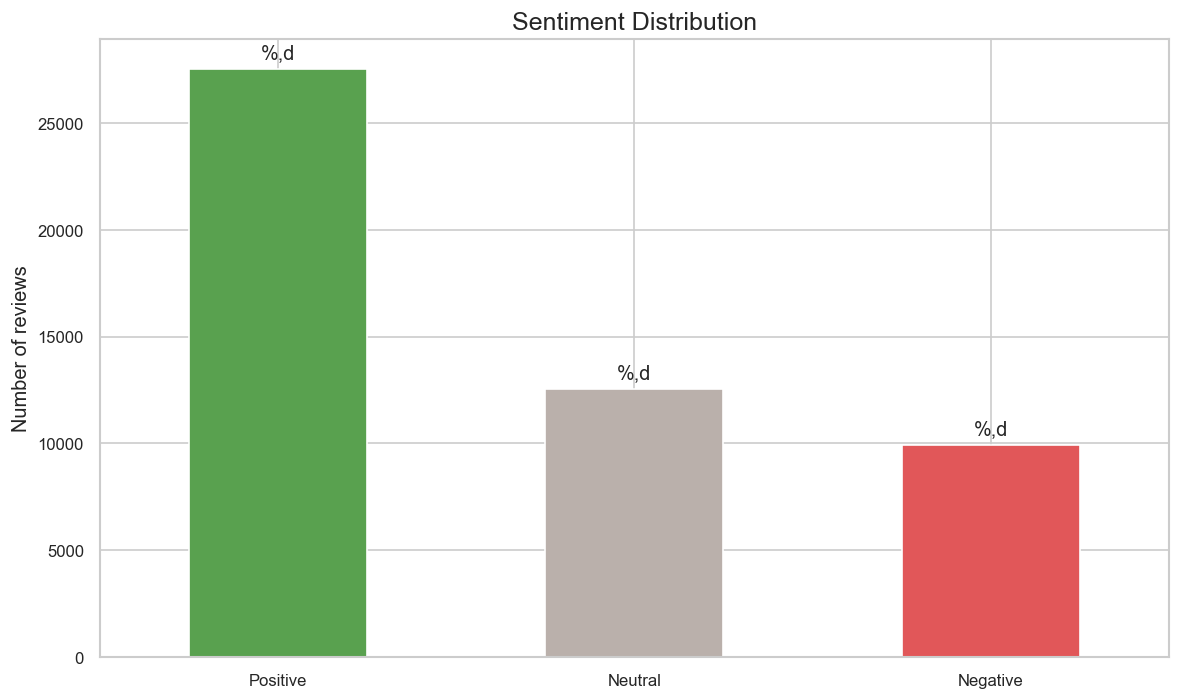

In [4]:
sentiment_counts = (
    df["sentiment"]
    .fillna("Missing")
    .value_counts()
)

fig, ax = plt.subplots(figsize=(10, 6))

colors = {
    "Positive": "#59a14f",
    "Negative": "#e15759",
    "Neutral": "#bab0ab",
    "Missing": "#79706e"
}

bar_colors = [
    colors.get(str(value), "#4e79a7")
    for value in sentiment_counts.index
]

sentiment_counts.plot.bar(
    ax=ax,
    color=bar_colors
)

ax.set_title("Sentiment Distribution")
ax.set_xlabel("")
ax.set_ylabel("Number of reviews")
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%,d",
        padding=4
    )

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "02_sentiment_distribution.png",
    bbox_inches="tight"
)
plt.show()

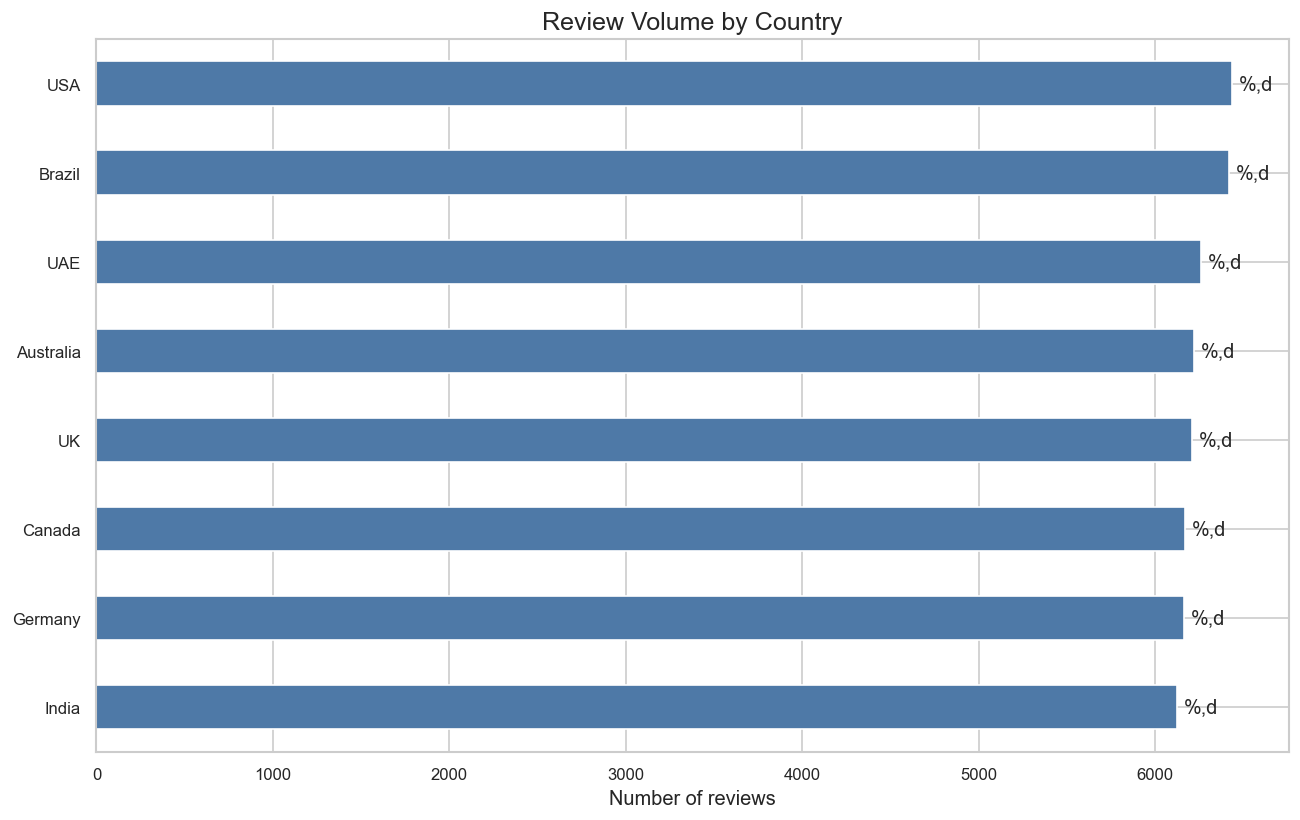

In [5]:
country_counts = (
    df["country"]
    .fillna("Missing")
    .value_counts()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(11, 7))

country_counts.plot.barh(
    ax=ax,
    color="#4e79a7"
)

ax.set_title("Review Volume by Country")
ax.set_xlabel("Number of reviews")
ax.set_ylabel("")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%,d",
        padding=4
    )

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "03_reviews_by_country.png",
    bbox_inches="tight"
)
plt.show()

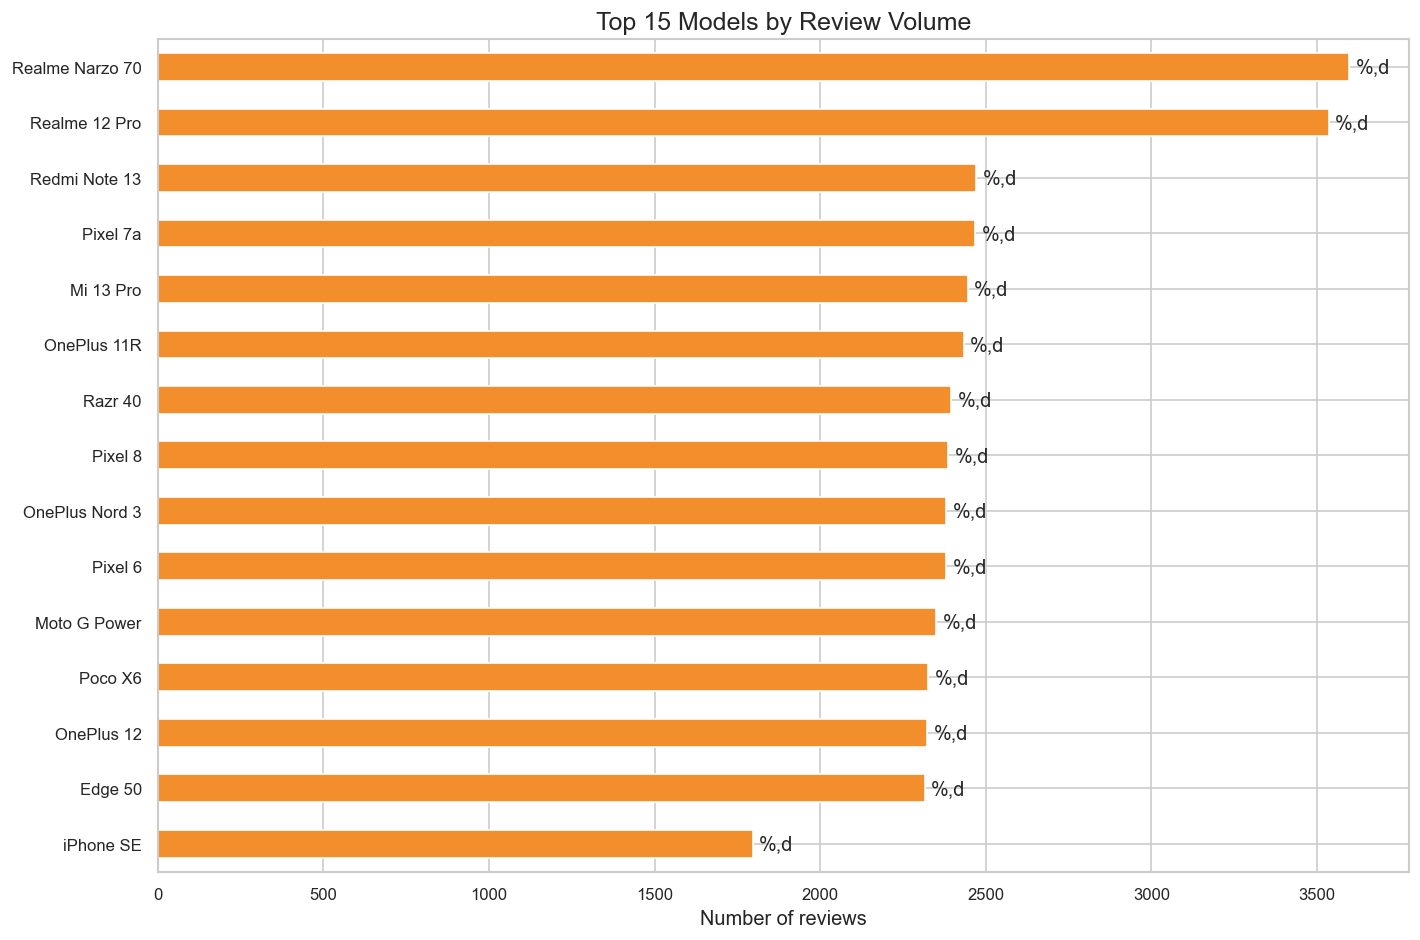

In [6]:
top_models = (
    df["model"]
    .fillna("Missing")
    .value_counts()
    .head(15)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(12, 8))

top_models.plot.barh(
    ax=ax,
    color="#f28e2b"
)

ax.set_title("Top 15 Models by Review Volume")
ax.set_xlabel("Number of reviews")
ax.set_ylabel("")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%,d",
        padding=4
    )

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "04_top_models.png",
    bbox_inches="tight"
)
plt.show()

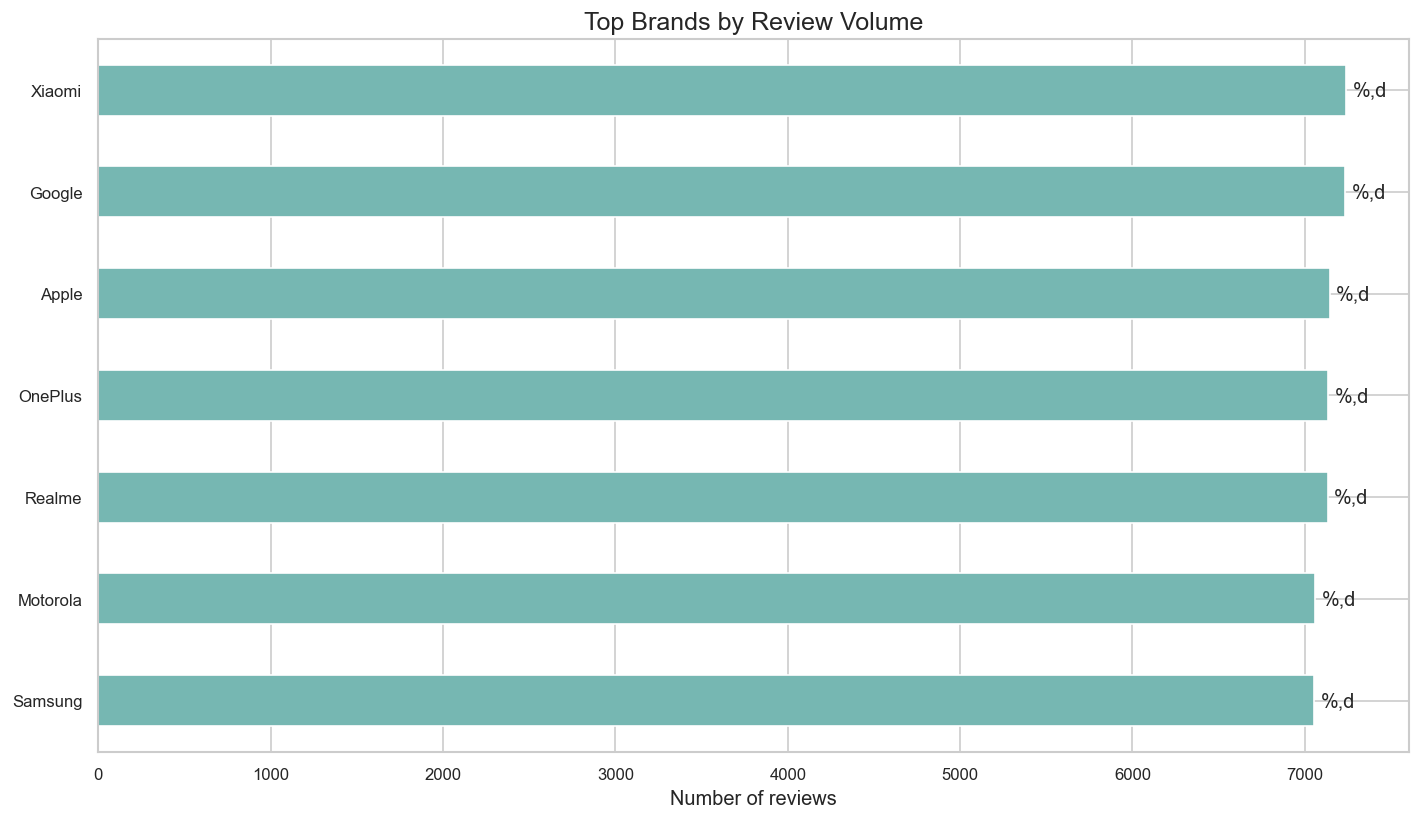

In [7]:
brand_counts = (
    df["brand"]
    .fillna("Missing")
    .value_counts()
    .head(15)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(12, 7))

brand_counts.plot.barh(
    ax=ax,
    color="#76b7b2"
)

ax.set_title("Top Brands by Review Volume")
ax.set_xlabel("Number of reviews")
ax.set_ylabel("")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%,d",
        padding=4
    )

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "05_top_brands.png",
    bbox_inches="tight"
)
plt.show()

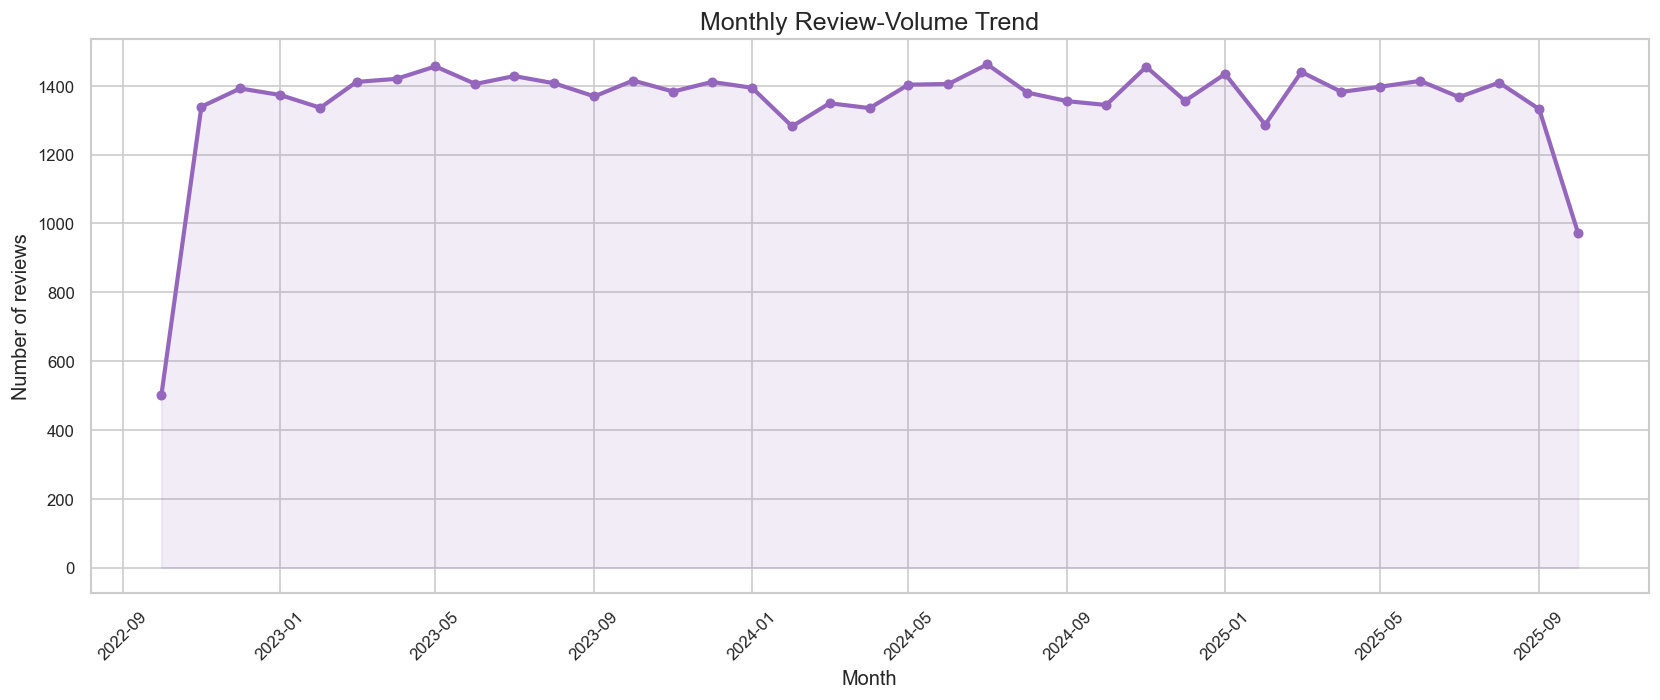

In [8]:
monthly_reviews = (
    df.dropna(subset=["month"])
    .groupby("month")
    .size()
)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    monthly_reviews.index,
    monthly_reviews.values,
    color="#9467bd",
    linewidth=2.5,
    marker="o",
    markersize=5
)

ax.fill_between(
    monthly_reviews.index,
    monthly_reviews.values,
    color="#9467bd",
    alpha=0.12
)

ax.set_title("Monthly Review-Volume Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Number of reviews")

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "06_monthly_review_trend.png",
    bbox_inches="tight"
)
plt.show()

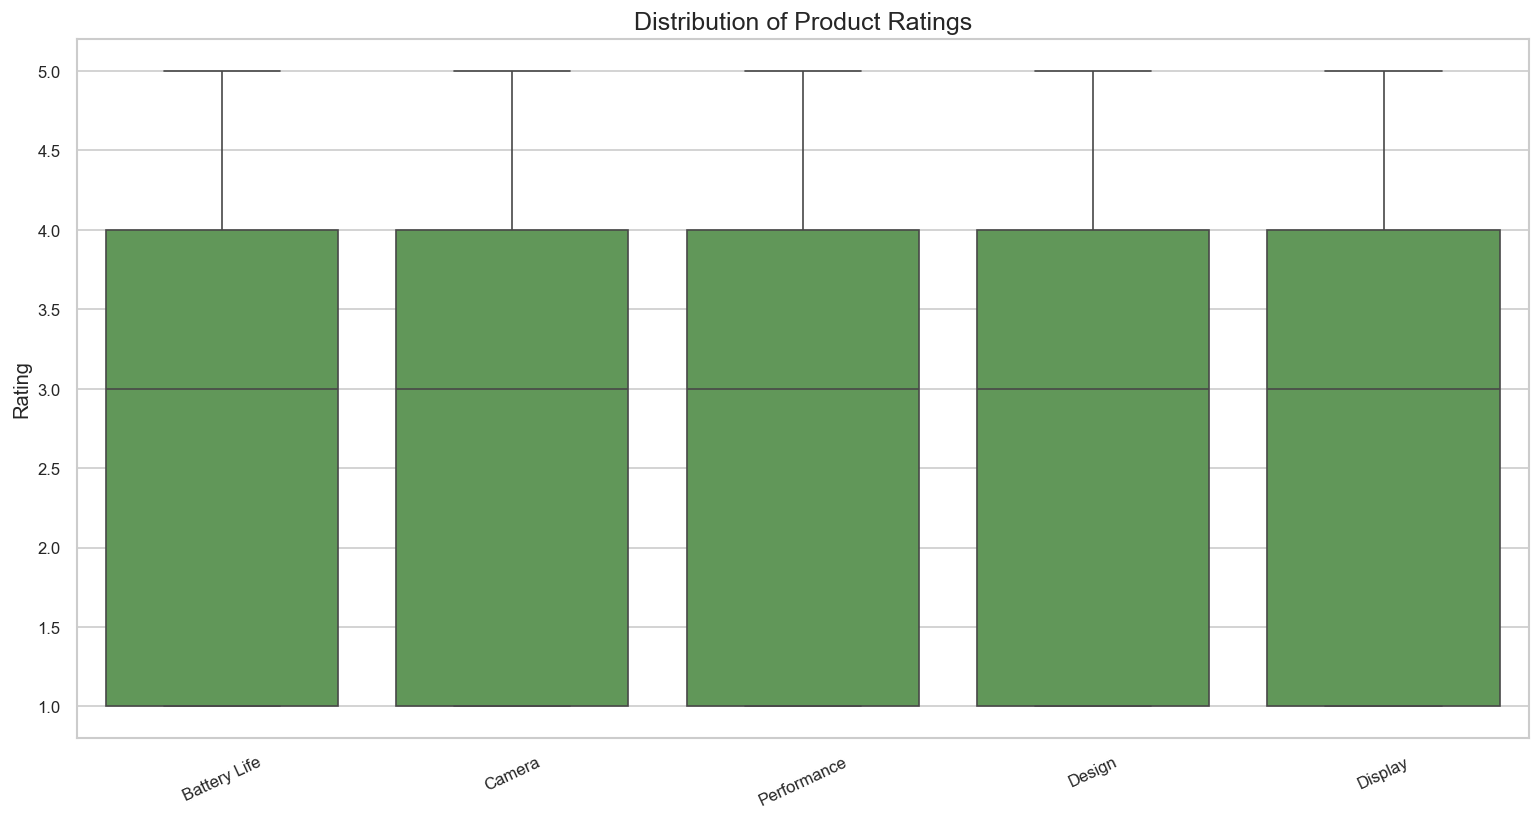

In [10]:
rating_columns = [
    
    "battery_life_rating",
    "camera_rating",
    "performance_rating",
    "design_rating",
    "display_rating"
]

rating_columns = [
    column
    for column in rating_columns
    if column in df.columns
]

rating_data = df[rating_columns].melt(
    var_name="feature",
    value_name="rating"
)

rating_data["feature"] = (
    rating_data["feature"]
    .str.replace("_rating", "", regex=False)
    .str.replace("_", " ", regex=False)
    .str.title()
)

fig, ax = plt.subplots(figsize=(13, 7))

sns.boxplot(
    data=rating_data,
    x="feature",
    y="rating",
    color="#59a14f",
    ax=ax
)

ax.set_title("Distribution of Product Ratings")
ax.set_xlabel("")
ax.set_ylabel("Rating")
ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "07_rating_distributions.png",
    bbox_inches="tight"
)
plt.show()

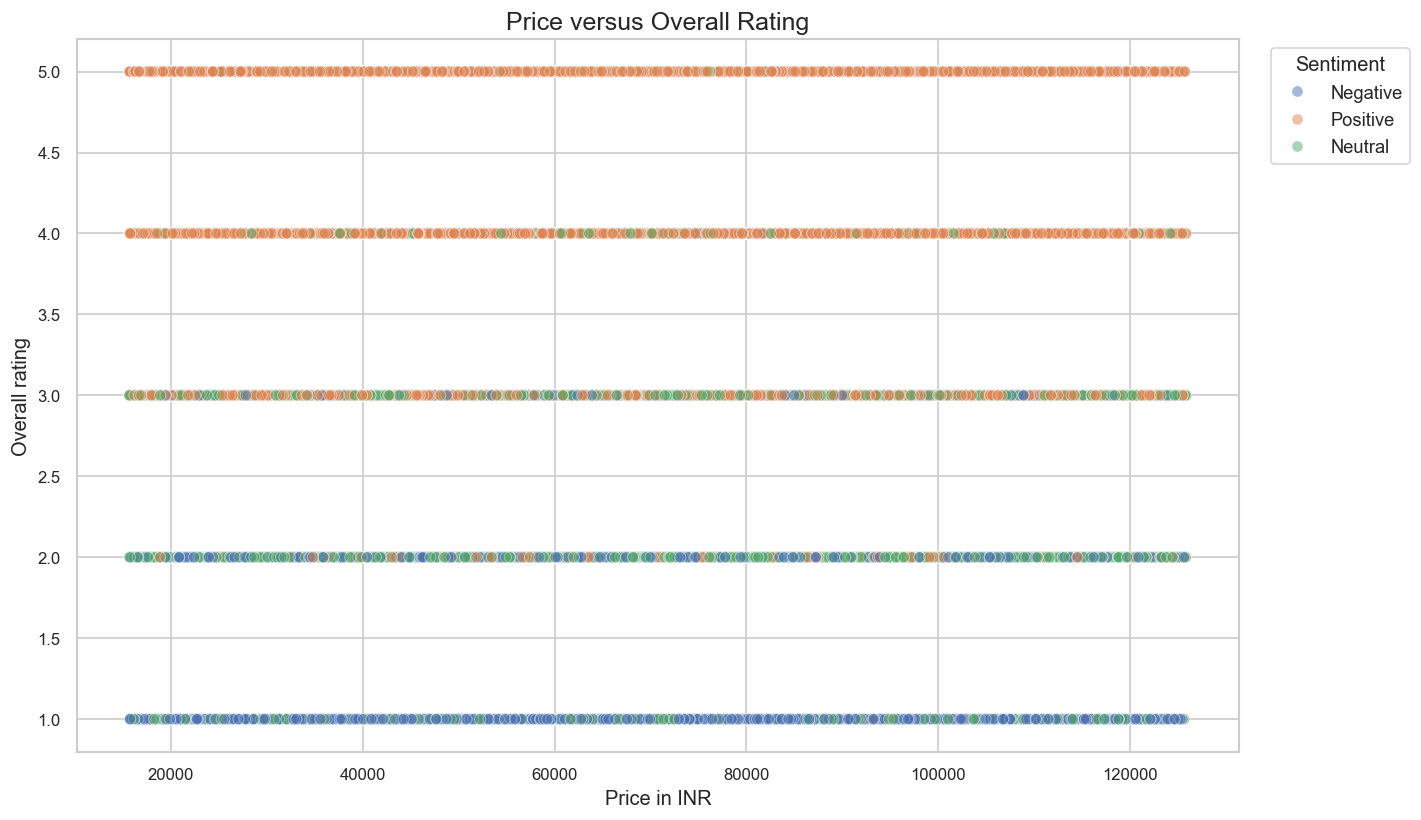

In [11]:
price_data = df[
    ["brand", "model", "price_inr", "rating", "sentiment"]
].dropna(
    subset=["price_inr", "rating"]
)

upper_limit = price_data["price_inr"].quantile(0.99)
price_data = price_data[
    price_data["price_inr"] <= upper_limit
]

fig, ax = plt.subplots(figsize=(12, 7))

sns.scatterplot(
    data=price_data,
    x="price_inr",
    y="rating",
    hue="sentiment",
    alpha=0.5,
    s=45,
    ax=ax
)

ax.set_title("Price versus Overall Rating")
ax.set_xlabel("Price in INR")
ax.set_ylabel("Overall rating")

ax.legend(
    title="Sentiment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "08_price_vs_rating.png",
    bbox_inches="tight"
)
plt.show()

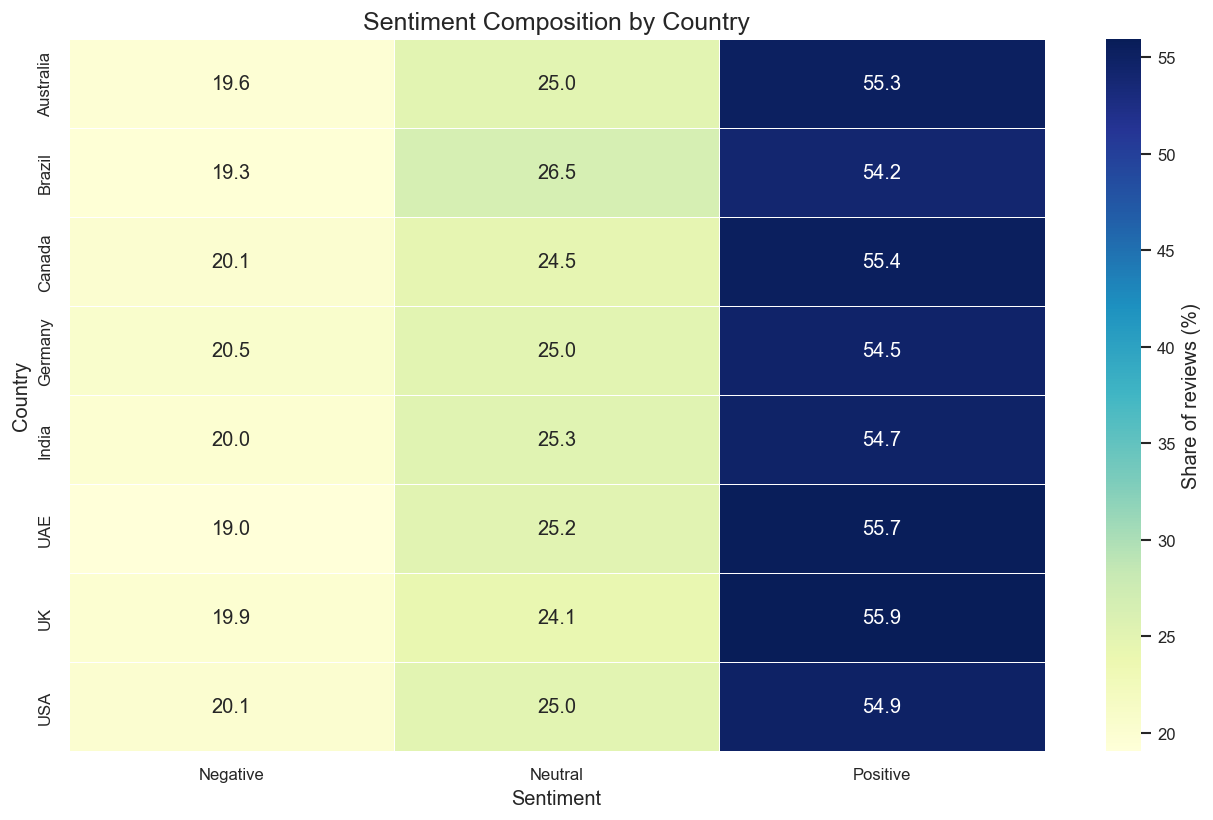

In [12]:
country_sentiment = pd.crosstab(
    df["country"],
    df["sentiment"],
    normalize="index"
).mul(100)

fig, ax = plt.subplots(figsize=(11, 7))

sns.heatmap(
    country_sentiment,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Share of reviews (%)"},
    ax=ax
)

ax.set_title("Sentiment Composition by Country")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Country")

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "09_country_sentiment_heatmap.png",
    bbox_inches="tight"
)
plt.show()

In [13]:
country_summary = (
    df.groupby("country")
    .agg(
        reviews=("review_id", "count"),
        positive_rate=("is_positive", "mean"),
        average_rating=("rating", "mean"),
        average_price_inr=("price_inr", "mean"),
        unique_models=("model", "nunique")
    )
    .sort_values(
        "reviews",
        ascending=False
    )
)

country_summary["positive_rate"] = (
    country_summary["positive_rate"]
    .mul(100)
    .round(2)
)

country_summary["average_rating"] = (
    country_summary["average_rating"]
    .round(2)
)

country_summary["average_price_inr"] = (
    country_summary["average_price_inr"]
    .round(0)
)

display(country_summary)

,reviews,positive_rate,average_rating,average_price_inr,unique_models
country,,,,,
USA,6435,54.90,3.12,59612.0,22
Brazil,6419,54.17,3.12,60262.0,22
UAE,6261,55.73,3.14,59898.0,22
Australia,6219,55.33,3.13,59996.0,22
UK,6210,55.94,3.13,59778.0,22
Canada,6170,55.40,3.12,59994.0,22
Germany,6162,54.51,3.11,60607.0,22
India,6124,54.69,3.12,59889.0,22


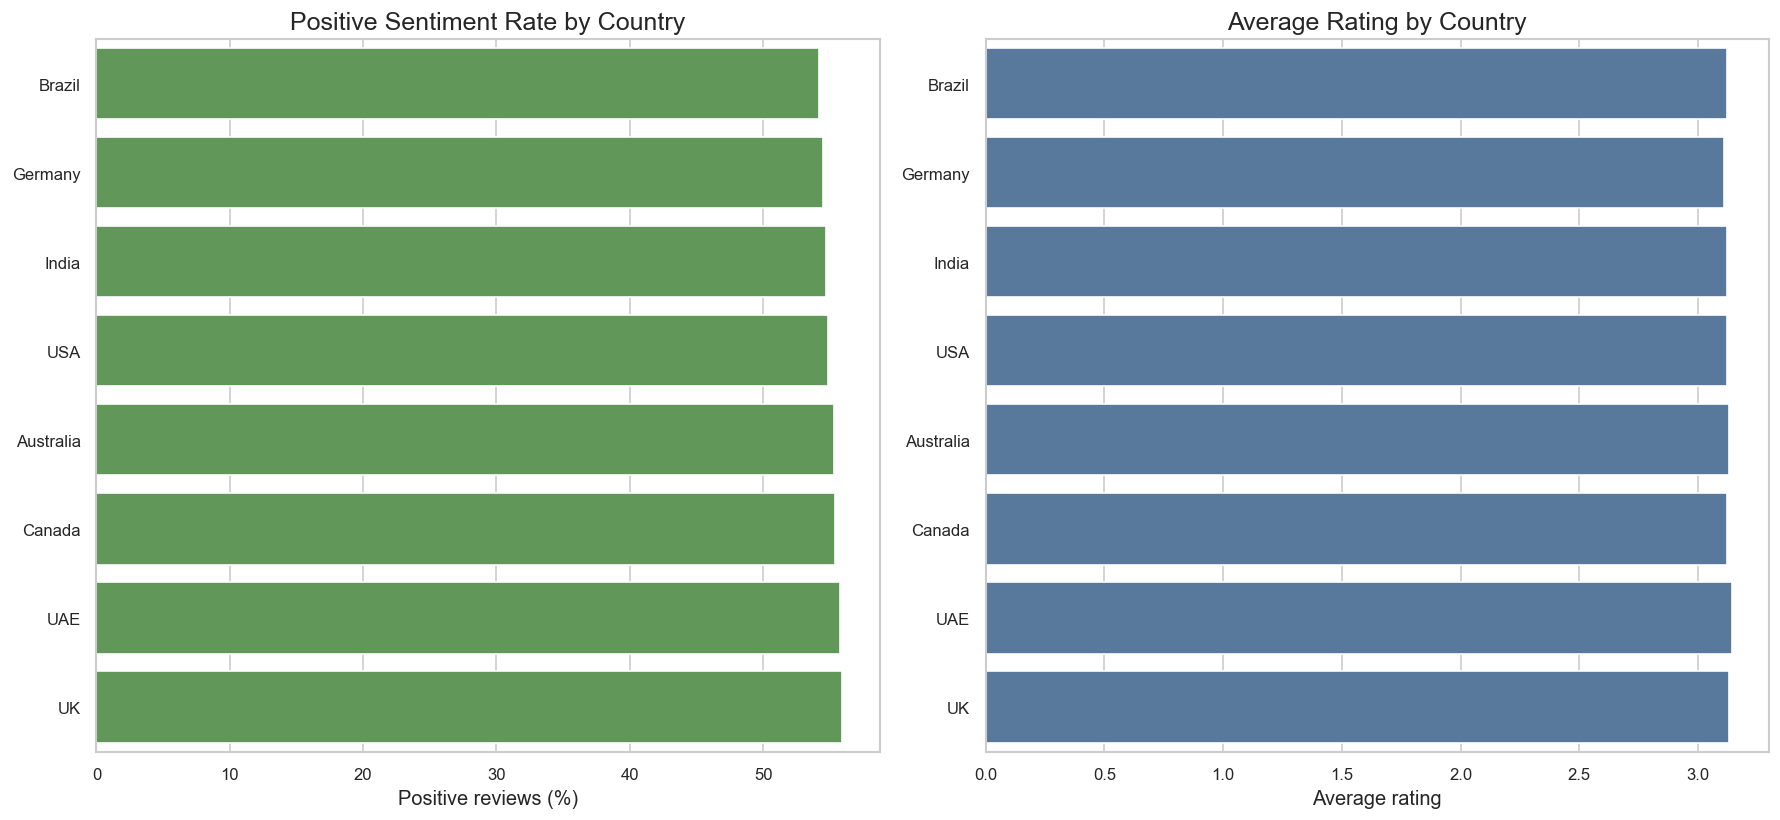

In [14]:
country_metrics = (
    country_summary
    .reset_index()
    .sort_values(
        "positive_rate",
        ascending=True
    )
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 7)
)

sns.barplot(
    data=country_metrics,
    x="positive_rate",
    y="country",
    color="#59a14f",
    ax=axes[0]
)

axes[0].set_title("Positive Sentiment Rate by Country")
axes[0].set_xlabel("Positive reviews (%)")
axes[0].set_ylabel("")

sns.barplot(
    data=country_metrics,
    x="average_rating",
    y="country",
    color="#4e79a7",
    ax=axes[1]
)

axes[1].set_title("Average Rating by Country")
axes[1].set_xlabel("Average rating")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "10_country_comparison.png",
    bbox_inches="tight"
)
plt.show()

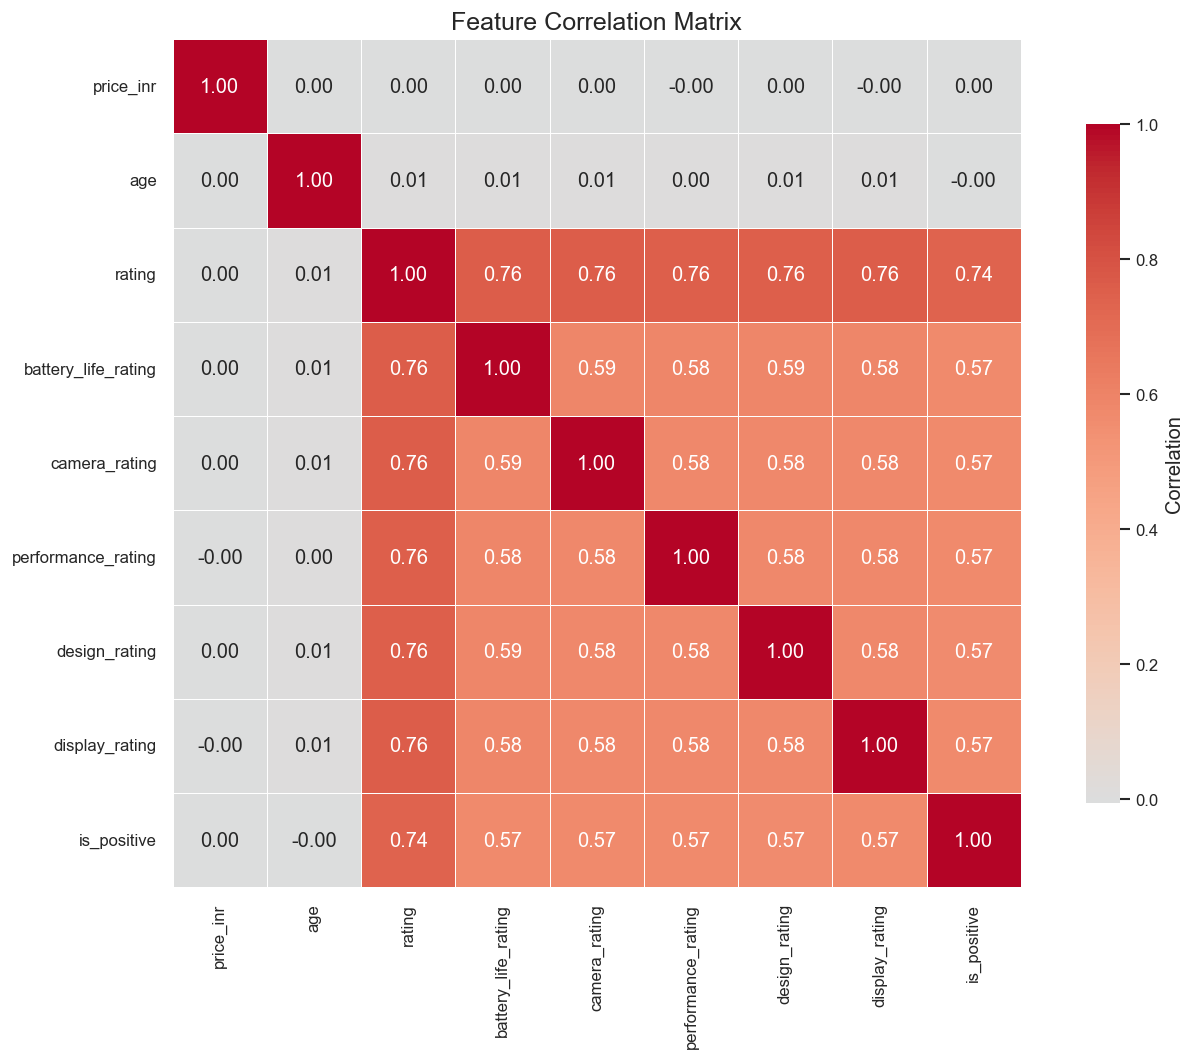

In [15]:
numeric_candidates = [
    "price_inr",
    "age",
    "rating",
    "battery_life_rating",
    "camera_rating",
    "performance_rating",
    "design_rating",
    "display_rating",
    "is_positive"
]

numeric_columns = [
    column
    for column in numeric_candidates
    if column in df.columns
]

correlation = df[numeric_columns].corr()

fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={
        "shrink": 0.8,
        "label": "Correlation"
    },
    ax=ax
)

ax.set_title("Feature Correlation Matrix")

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "11_correlation_matrix.png",
    bbox_inches="tight"
)
plt.show()

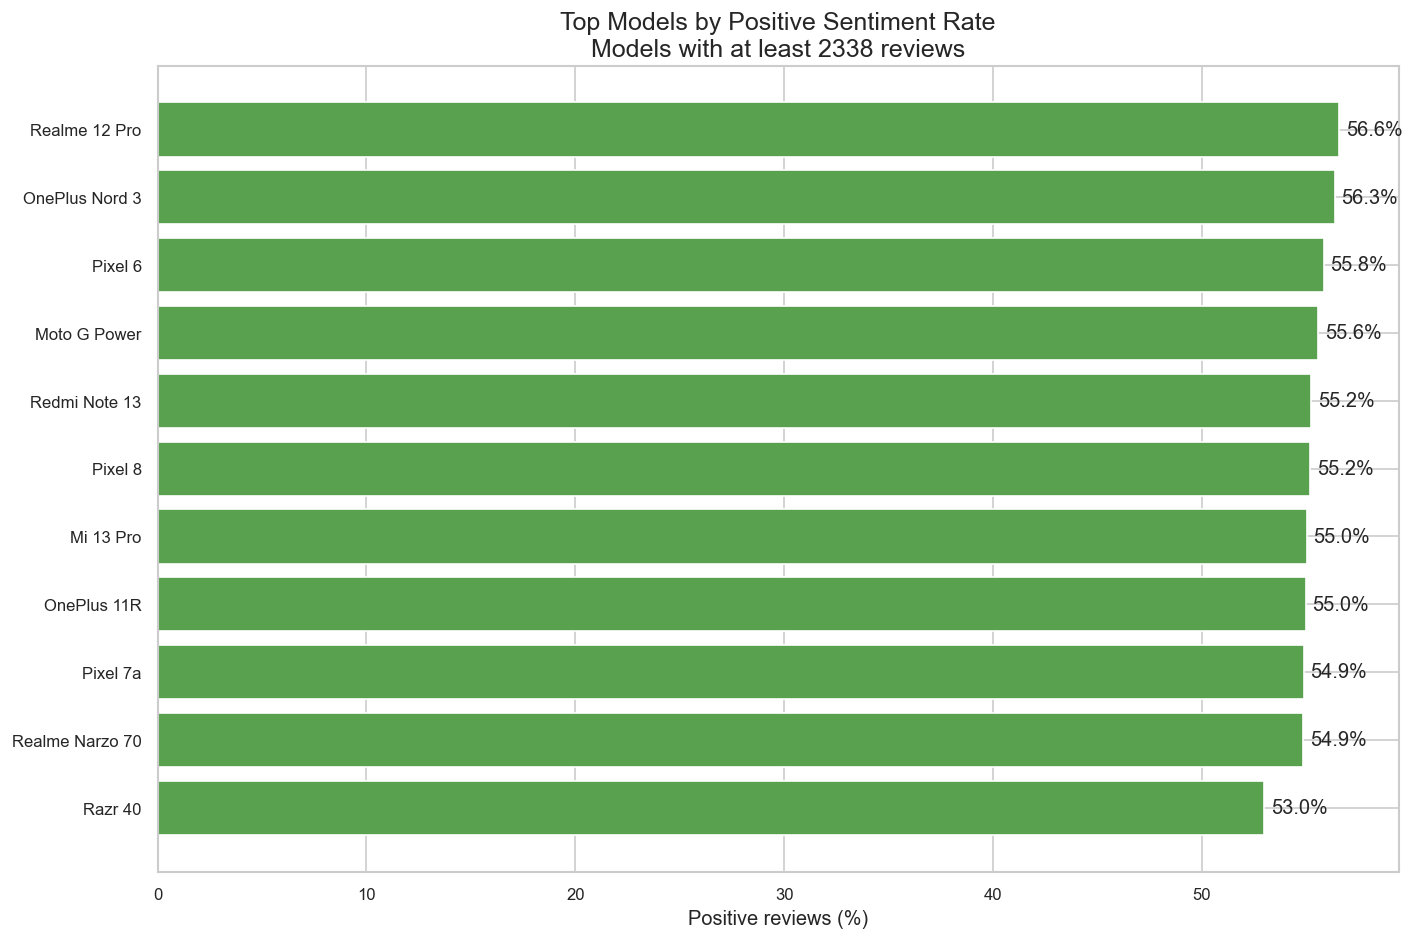

,brand,model,reviews,positive_rate,average_rating,average_price_inr
13,Realme,Realme 12 Pro,3535,56.577086,3.145686,34257.169960
12,OnePlus,OnePlus Nord 3,2380,56.344538,3.137815,58675.133282
4,Google,Pixel 6,2379,55.821774,3.116435,70295.493871
8,Motorola,Moto G Power,2351,55.550829,3.137388,43898.803781
21,Xiaomi,Redmi Note 13,2470,55.222672,3.126316,39132.733142
6,Google,Pixel 8,2387,55.173858,3.119397,69516.894407
19,Xiaomi,Mi 13 Pro,2445,55.010225,3.094888,39053.143558
10,OnePlus,OnePlus 11R,2433,54.952733,3.120016,58533.017139
5,Google,Pixel 7a,2468,54.862237,3.131280,70199.716592
14,Realme,Realme Narzo 70,3597,54.851265,3.132054,34163.306088


In [16]:
model_summary = (
    df.groupby(["brand", "model"])
    .agg(
        reviews=("review_id", "count"),
        positive_rate=("is_positive", "mean"),
        average_rating=("rating", "mean"),
        average_price_inr=("price_inr", "mean")
    )
    .reset_index()
)

model_summary["positive_rate"] *= 100

minimum_reviews = model_summary["reviews"].quantile(0.50)

top_products = (
    model_summary[
        model_summary["reviews"] >= minimum_reviews
    ]
    .sort_values(
        ["positive_rate", "reviews"],
        ascending=[False, False]
    )
    .head(15)
    .sort_values("positive_rate")
)

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    top_products["model"],
    top_products["positive_rate"],
    color="#59a14f"
)

ax.set_title(
    "Top Models by Positive Sentiment Rate\n"
    f"Models with at least {minimum_reviews:.0f} reviews"
)

ax.set_xlabel("Positive reviews (%)")
ax.set_ylabel("")

ax.bar_label(
    bars,
    fmt="%.1f%%",
    padding=4
)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "12_top_models_by_sentiment.png",
    bbox_inches="tight"
)
plt.show()

display(
    top_products.sort_values(
        "positive_rate",
        ascending=False
    )
)

In [17]:
print(f"EDA images saved to: {OUTPUT_DIR.resolve()}")

for file_path in sorted(OUTPUT_DIR.glob("*.png")):
    print(file_path.name)

EDA images saved to: /Users/sameerkumar/Downloads/eda_outputs
02_sentiment_distribution.png
03_reviews_by_country.png
04_top_models.png
05_top_brands.png
06_monthly_review_trend.png
07_rating_distributions.png
08_price_vs_rating.png
09_country_sentiment_heatmap.png
10_country_comparison.png
11_correlation_matrix.png
12_top_models_by_sentiment.png
